In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import talib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data_path = r'C:\Users\PC\Desktop\News_Sentiment\data\raw\yfinance\Data'
#glob - Find all files matching a specified pattern
#os- provides a way to interact with computer's file system
# Find all CSV files in that folder
stock_files = glob.glob(f'{data_path}\\*.csv')

# Load and combine all stock files
stock_data = [] #at this point the stcok_data is a list of separate Dataframes

for file in stock_files:
    ticker = os.path.basename(file).replace('.csv', '') #extract the filename from full file path and remove the .csv
    df = pd.read_csv(file)
    df['Ticker'] = ticker
    stock_data.append(df)
    print(f"Loaded {ticker}: {len(df)} rows")

# but here we are combining all the separate Dataframes from stock_data in to one big dataframe
df_all_stocks = pd.concat(stock_data, ignore_index=True)

print("Combined DataFrames")
df.head()

Loaded AAPL: 3774 rows
Loaded AMZN: 3774 rows
Loaded GOOG: 3774 rows
Loaded META: 2923 rows
Loaded NVDA: 3774 rows
Combined DataFrames


,Date,Close,High,Low,Open,Volume,Ticker
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000,NVDA
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000,NVDA
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000,NVDA
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000,NVDA
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000,NVDA


## Task 2: Loading and Combining Stock Data

### Data Source

The stock price data was sourced from multiple CSV files, one per stock ticker:

| Ticker | Company | Rows |
|--------|---------|------|
| AAPL | Apple Inc. | 3,774 |
| AMZN | Amazon.com Inc. | 3,774 |
| GOOG | Alphabet Inc. | 3,774 |
| META | Meta Platforms Inc. | 2,923 |
| NVDA | NVIDIA Corporation | 3,774 |

### Loading Process

The following steps were performed to load and combine the data:

#### 1. File Discovery
```python
stock_files = glob.glob(f'{data_path}\\*.csv')
```
#### 2. Individual file loading
For each CSV file found, the ticker name is extracted, loaded to pandas DataFrame and Ticker column is added
#### 3. Combinig DataFrames
stack all individual Dataframes from step 2 to a single big DataFrame and reset row index value so there won't be duplicated index value

In [3]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker'], dtype='str')

In [4]:
print(df.isnull().sum())

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64


The above result shows that there are no missing values for each row

In [5]:
print(df.duplicated().sum())

0


The above result shows there are no duplicated result in the given dataset 

In [6]:
#now let us prepare our (AAPL) for TA-Lib
aapl = df_all_stocks[df_all_stocks['Ticker'] =='AAPL'].copy()
aapl.head()
#now lets order th data by date
aapl=aapl.sort_values('Date').reset_index(drop=True)

In [7]:
close_prices = aapl['Close'].values
high_prices =aapl['High'].values
low_prices=aapl['Low'].values
open_prices=aapl['Open'].values
volumes=aapl['Volume'].values
close_prices[:5]

array([2.72168636, 2.83655286, 2.78976679, 2.72948384, 2.78016925])

In [8]:
# Check if you actually have 10 days of data before index 9
print(f"Total rows in AAPL: {len(aapl)}")
print(f"First 10 rows:")
print(aapl[['Date', 'Close']].head(10))

Total rows in AAPL: 3774
First 10 rows:
         Date     Close
0  2009-01-02  2.721686
1  2009-01-05  2.836553
2  2009-01-06  2.789767
3  2009-01-07  2.729484
4  2009-01-08  2.780169
5  2009-01-09  2.716589
6  2009-01-12  2.659007
7  2009-01-13  2.630514
8  2009-01-14  2.559135
9  2009-01-15  2.500652


In [9]:
#Simple Moving Average (SMA) for 10, 20, 50, and 200 days
aapl['SMA_10'] = aapl['Close'].rolling(window=10).mean()
aapl['SMA_20'] = aapl['Close'].rolling(window=20).mean()
aapl['SMA_50'] = aapl['Close'].rolling(window=50).mean()
aapl['SMA_200'] = aapl['Close'].rolling(window=200).mean()
aapl.head(200)

,Date,Close,High,Low,Open,Volume,Ticker,SMA_10,SMA_20,SMA_50,SMA_200
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL,NaN,NaN,NaN,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL,NaN,NaN,NaN,NaN
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL,NaN,NaN,NaN,NaN
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,AAPL,NaN,NaN,NaN,NaN
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,AAPL,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
195,2009-10-12,5.722591,5.743585,5.687501,5.728889,288024800,AAPL,5.618282,5.557730,5.235237,NaN
196,2009-10-13,5.698898,5.733388,5.689301,5.717192,348020400,AAPL,5.632198,5.580014,5.249386,NaN
197,2009-10-14,5.736986,5.767876,5.705196,5.765777,375510800,AAPL,5.650013,5.594139,5.264826,NaN
198,2009-10-15,5.715095,5.725891,5.684204,5.687203,373556400,AAPL,5.679104,5.603152,5.280091,NaN


## Moving Averages Calculation Results

### Overview

The Simple Moving Averages (SMA) were calculated for AAPL stock using daily closing prices over the period from January 2, 2009 to October 16, 2009.

### SMA Values at Key Checkpoints

| Date (Index) | SMA_10 | SMA_20 | SMA_50 | SMA_200 | Interpretation |
|--------------|--------|--------|--------|---------|----------------|
| 2009-01-15 (Index 9) | 2.692 | NaN | NaN | NaN | SMA_10 becomes active (10 trading days completed) |
| 2009-10-12 (Index 195) | 5.618 | 5.558 | 5.235 | NaN | SMA_50 active; SMA_200 still pending |
| 2009-10-16 (Index 199) | 5.689 | 5.608 | 5.295 | **3.994** | SMA_200 becomes active!|

### Observations

**SMA_10 (10-day moving average):**
- First valid value: January 15, 2009 (2.692)
- Most recent value (Oct 16, 2009): 5.689
- Sensitivity: High (reacts quickly to price changes)

**SMA_20 (20-day moving average):**
- First valid value: Approximately late January 2009
- Most recent value (Oct 16, 2009): 5.608
- Use case: Medium-term trend identification

**SMA_50 (50-day moving average):**
- First valid value: Approximately mid-March 2009
- Most recent value (Oct 16, 2009): 5.295
- Use case: Intermediate trend confirmation

**SMA_200 (200-day moving average):**
- First valid value: **October 16, 2009 (3.994)**
- Use case: Long-term trend (bull/bear market indicator)

### Price vs Moving Average Relationship (as of Oct 16, 2009)

| Indicator | Value | Price (5.640) Position | Signal |
|-----------|-------|----------------------|--------|
| SMA_10 | 5.689 | Below | Slightly Bearish |
| SMA_20 | 5.608 | Above | Bullish |
| SMA_50 | 5.295 | Above | Bullish |
| SMA_200 | 3.994 | Above | Strongly Bullish|

### Key Takeaway

By October 16, 2009, AAPL was trading above all major moving averages (SMA_20, SMA_50, and SMA_200), confirming a **bullish long-term trend**. The price being slightly below the SMA_10 suggests short-term weakness, but the overall trend remains positive.

In [10]:
aapl['EMA_9']=talib.EMA(close_prices,timeperiod=9)
aapl['EMA_12']=talib.EMA(close_prices,timeperiod=12)
aapl['EMA_20']=talib.EMA(close_prices,timeperiod=20)
aapl['EMA_26']=talib.EMA(close_prices,timeperiod=26)
aapl['EMA_50']=talib.EMA(close_prices,timeperiod=50)
aapl.head(50)

,Date,Close,High,Low,Open,Volume,Ticker,SMA_10,SMA_20,SMA_50,SMA_200,EMA_9,EMA_12,EMA_20,EMA_26,EMA_50
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2009-01-09,2.716589,2.800564,2.703393,2.795466,546845600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2009-01-12,2.659007,2.728886,2.625717,2.712990,617716400,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2009-01-13,2.630514,2.691395,2.589726,2.646409,798397600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2009-01-14,2.559135,2.616717,2.540840,2.586427,1021664000,AAPL,NaN,NaN,NaN,NaN,2.713656,NaN,NaN,NaN,NaN
9,2009-01-15,2.500652,2.522846,2.400782,2.416377,1831634000,AAPL,2.692356,NaN,NaN,NaN,2.671055,NaN,NaN,NaN,NaN


## Exponential Moving Averages (EMA) - Initial Period Analysis for AAPL

### Overview

The Exponential Moving Average (EMA) gives more weight to recent prices, making it more responsive to new information than the Simple Moving Average (SMA). The table below shows the first 50 rows of AAPL data with various EMA periods.

### EMA Parameters Calculated

| Indicator | Time Period | Use Case |
|-----------|-------------|----------|
| EMA_9 | 9 days | Very short-term momentum |
| EMA_10 | 10 days | Short-term trend |
| EMA_12 | 12 days | Short-term (often used with EMA_26 for MACD) |
| EMA_20 | 20 days | Short to medium-term trend |
| EMA_26 | 26 days | Medium-term (used in MACD calculation) |
| EMA_50 | 50 days | Intermediate trend |


---

### EMA Activation Timeline (Based on Data)

| EMA Period | First Valid Index | First Valid Date | First Value |
|------------|-------------------|------------------|-------------|
| EMA_9 | Index 8 | 2009-01-14 | 2.713656 |
| EMA_10 | Index 9 | 2009-01-15 | 2.692356 |
| EMA_12 | Index 11 | 2009-01-20 | 2.644835 |
| EMA_20 | Index 19 | 2009-01-30 | 2.662455 |
| EMA_26 | Index 25 | 2009-02-09 | 2.713301 |
| EMA_50 | Index 49 | 2009-03-16 | 2.733174 |

---

### Key Observations (First 50 Trading Days)

**EMA_9 (9-day, most responsive):**
- First value: 2.713656 (Index 8)
- Reacts quickest to price changes
- Shows the most volatility among EMAs

**EMA_20 (20-day):**
- First value: 2.662455 (Index 19)
- Smoother than shorter-term EMAs
- Commonly used for short-term trend identification

**EMA_50 (50-day):**
- First value: 2.733174 (Index 49)
- Only becomes active near the end of this period
- Will serve as intermediate trend indicator

**EMA_26 (26-day):**
- First value: 2.713301 (Index 25)
- Used in MACD calculation (along with EMA_12)
- Important for momentum analysis in Task 3

---

### EMA vs SMA Comparison (Early Period)

| Date (Index) | Close | SMA_10 | EMA_10 | Difference |
|--------------|-------|--------|--------|------------|
| 2009-01-15 (9) | 2.500652 | 2.692356 | 2.692356 | 0.000 |
| 2009-01-16 (10) | 2.469163 | 2.667103 | 2.651775 | -0.015 |
| 2009-01-20 (11) | 2.345299 | 2.617978 | 2.596052 | -0.022 |
| 2009-01-21 (12) | 2.484158 | 2.587417 | 2.575708 | -0.012 |

**Observation:** EMA consistently stays slightly below SMA during this downward price movement, demonstrating its faster reaction to recent price declines.

---

### Data Quality Note

- NULL values in early rows (Indices 0-7 for EMA_9, 0-8 for EMA_10, etc.) are **expected behavior**
- EMA calculations require N data points before producing valid values
- EMA_50 first appears at Index 49 (March 16, 2009)
- EMA_200 is not visible in this period (requires 200 trading days)

---

### Next Steps

1. EMA_12 and EMA_26 will be used for MACD calculation
2. EMA_20 and EMA_50 will help identify medium-term trends
3. All EMAs will be correlated with news sentiment in Task 3

---

### EMA vs SMA Summary

| Characteristic | SMA | EMA |
|----------------|-----|-----|
| Weight distribution | Equal to all days | More weight to recent days |
| Reaction speed | Slower | Faster |
| Noise filtering | Better | Worse |
| Best for | Long-term trends | Short-term trends |
| Calculation complexity | Simple | Moderate |

**Interpretation:** In the early period (January-February 2009), AAPL was experiencing downward price movement. The EMA reacted faster to this decline, staying consistently below the SMA during this period.

In [11]:
#Prepare AMZN.csv for TaLib
amzn =df_all_stocks[df_all_stocks['Ticker']=='AMZN'].copy()
amzn.head()
amzn=amzn.sort_values('Date').reset_index(drop=True)
amzn.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2009-01-02,2.718,2.7265,2.5535,2.5675,145928000,AMZN
1,2009-01-05,2.703,2.7870,2.6515,2.7865,190196000,AMZN
2,2009-01-06,2.868,2.9110,2.6875,2.7275,221602000,AMZN
3,2009-01-07,2.810,2.8475,2.7675,2.8145,158854000,AMZN
4,2009-01-08,2.858,2.8660,2.7290,2.7495,131558000,AMZN


In [12]:
close_prices_amzn = amzn['Close'].values
high_prices_amzn =amzn['High'].values   
low_prices_amzn=amzn['Low'].values
open_prices_amzn=amzn['Open'].values
volumes_amzn=amzn['Volume'].values

In [13]:
#Simple Moving Average (SMA) for 10, 20, 50, and 200 days for AMZN
amzn['SMA-10']=amzn['Close'].rolling(window=10).mean()
amzn['SMA-20']=amzn['Close'].rolling(window=20).mean()
amzn['SMA-50']=amzn['Close'].rolling(window=50).mean()
amzn['SMA-200']=amzn['Close'].rolling(window=200).mean()
amzn.head(200)

,Date,Close,High,Low,Open,Volume,Ticker,SMA-10,SMA-20,SMA-50,SMA-200
0,2009-01-02,2.7180,2.7265,2.5535,2.5675,145928000,AMZN,NaN,NaN,NaN,NaN
1,2009-01-05,2.7030,2.7870,2.6515,2.7865,190196000,AMZN,NaN,NaN,NaN,NaN
2,2009-01-06,2.8680,2.9110,2.6875,2.7275,221602000,AMZN,NaN,NaN,NaN,NaN
3,2009-01-07,2.8100,2.8475,2.7675,2.8145,158854000,AMZN,NaN,NaN,NaN,NaN
4,2009-01-08,2.8580,2.8660,2.7290,2.7495,131558000,AMZN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
195,2009-10-12,4.6800,4.8125,4.6535,4.8085,111828000,AMZN,4.62025,4.576375,4.32625,NaN
196,2009-10-13,4.7415,4.7625,4.6840,4.6915,94400000,AMZN,4.63580,4.604575,4.33364,NaN
197,2009-10-14,4.8730,4.8910,4.8010,4.8110,111136000,AMZN,4.65630,4.621475,4.34530,NaN
198,2009-10-15,4.8005,4.8530,4.7540,4.7565,124842000,AMZN,4.68115,4.635400,4.35702,NaN


## AMZN - Simple Moving Averages Analysis

### Overview

Simple Moving Averages (SMA) were calculated for Amazon (AMZN) stock using daily closing prices. SMAs smooth price data to identify trends over different time horizons.

### SMA Parameters

| Indicator | Time Period | Use Case |
|-----------|-------------|----------|
| SMA-10 | 10 days | Short-term trend |
| SMA-20 | 20 days | Medium-term trend |
| SMA-50 | 50 days | Intermediate trend |
| SMA-200 | 200 days | Long-term trend (bull/bear market indicator) |

---

### SMA Activation Timeline

| SMA | First Valid Index | First Valid Date | First Value |
|-----|-------------------|------------------|-------------|
| SMA-10 | Index 9 | 2009-01-15 | 2.68975 |
| SMA-20 | Index 19 | 2009-01-30 | 2.61585 |
| SMA-50 | Index 49 | 2009-03-16 | 2.96633 |
| SMA-200 | Index 199 | 2009-10-16 | 3.83770 |

---

### Key Observations (First 50 Trading Days)

**Price Movement Context (Jan-Mar 2009):**
- Starting price: $2.718 (Jan 2, 2009)
- Price range: $2.3815 - $3.4935
- Significant volatility during the period

**SMA-10 (10-day):**
- First value: 2.68975 (Index 9)
- Reacts quickly to price changes
- Crosses above and below price multiple times

**SMA-20 (20-day):**
- First value: 2.61585 (Index 19)
- Smoother than SMA-10
- Begins to show upward trend by end of period

**SMA-50 (50-day):**
- First value: 2.96633 (Index 49)
- Only becomes active near the end of this period
- Will serve as intermediate trend indicator moving forward

**SMA-200 (200-day):**
- Not yet active in this period (requires 200 trading days)
- First appears October 16, 2009 at 3.83770

---

### SMA Values at Key Dates (First 50 Days)

| Date (Index) | Close | SMA-10 | SMA-20 | Price vs SMA-10 |
|--------------|-------|--------|--------|-----------------|
| 2009-01-15 (9) | 2.5720 | 2.68975 | NaN | Below |
| 2009-01-30 (19) | 2.9410 | 2.54195 | 2.61585 | Above |
| 2009-02-09 (25) | 3.3355 | 2.94930 | 2.73483 | Above |
| 2009-02-20 (33) | 3.1930 | 3.18985 | 2.98708 | Above |
| 2009-03-16 (49) | 3.3490 | 3.26450 | 3.20718 | Above |

---

### AMZN vs AAPL SMA Comparison (First 50 Days)

| Stock | SMA-10 First Value | SMA-20 First Value | Price at Index 49 |
|-------|-------------------|-------------------|-------------------|
| AAPL | 2.69236 | 2.66246 | 2.86175 |
| AMZN | 2.68975 | 2.61585 | 3.34900 |

**Observation:** AMZN showed stronger price appreciation during this period, rising from $2.718 to $3.349 (+23%), while AAPL remained relatively flat.

---

### Data Quality Note

- NULL values in early rows are **expected behavior**
- Each SMA requires N days of data before producing valid values
- SMA-50 first valid at Index 49 (March 16, 2009)
- SMA-200 will first appear at Index 199 (October 16, 2009)

---

### Interpretation for AMZN

| Indicator | Signal |
|-----------|--------|
| Price vs SMA-10 | Above (bullish) by end of period |
| Price vs SMA-20 | Above (bullish) by end of period |
| Trend direction | Upward from mid-February 2009 |

**Key Takeaway:** AMZN showed strong bullish momentum in early 2009, consistently trading above its short-term moving averages from late January onward.

In [14]:
#calculate EMA for AMZN
amzn['EMA_9']=talib.EMA(close_prices_amzn,timeperiod=9)
amzn['EMA_12']=talib.EMA(close_prices_amzn,timeperiod=12)
amzn['EMA_20']=talib.EMA(close_prices_amzn,timeperiod=20)
amzn['EMA_26']=talib.EMA(close_prices_amzn,timeperiod=26)
amzn['EMA_50']=talib.EMA(close_prices_amzn,timeperiod=50)
amzn.head(50)

,Date,Close,High,Low,Open,Volume,Ticker,SMA-10,SMA-20,SMA-50,SMA-200,EMA_9,EMA_12,EMA_20,EMA_26,EMA_50
0,2009-01-02,2.7180,2.7265,2.5535,2.5675,145928000,AMZN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,2.7030,2.7870,2.6515,2.7865,190196000,AMZN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-06,2.8680,2.9110,2.6875,2.7275,221602000,AMZN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-07,2.8100,2.8475,2.7675,2.8145,158854000,AMZN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-08,2.8580,2.8660,2.7290,2.7495,131558000,AMZN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2009-01-09,2.7755,2.8500,2.7350,2.8460,133682000,AMZN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2009-01-12,2.5960,2.7150,2.5435,2.7060,191126000,AMZN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2009-01-13,2.5725,2.6645,2.5375,2.5480,157664000,AMZN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2009-01-14,2.4245,2.5050,2.4070,2.5050,208852000,AMZN,NaN,NaN,NaN,NaN,2.702833,NaN,NaN,NaN,NaN
9,2009-01-15,2.5720,2.6115,2.3815,2.4280,232346000,AMZN,2.68975,NaN,NaN,NaN,2.676667,NaN,NaN,NaN,NaN


## AMZN - Exponential Moving Averages Analysis

### Overview

Exponential Moving Averages (EMA) give more weight to recent prices, making them more responsive to new information than Simple Moving Averages.

### EMA Parameters

| Indicator | Time Period | Use Case |
|-----------|-------------|----------|
| EMA_9 | 9 days | Very short-term momentum |
| EMA_12 | 12 days | Short-term trend (used with EMA_26 for MACD) |
| EMA_20 | 20 days | Short to medium-term trend |
| EMA_26 | 26 days | Medium-term (used in MACD calculation) |
| EMA_50 | 50 days | Intermediate trend |

*Note: EMA_200 calculated separately for long-term analysis*

---

### EMA Activation Timeline

| EMA | First Valid Index | First Valid Date | First Value |
|-----|-------------------|------------------|-------------|
| EMA_9 | Index 8 | 2009-01-14 | 2.702833 |
| EMA_12 | Index 11 | 2009-01-20 | 2.658250 |
| EMA_20 | Index 19 | 2009-01-30 | 2.615850 |
| EMA_26 | Index 25 | 2009-02-09 | 2.747269 |
| EMA_50 | Index 49 | 2009-03-16 | 2.966330 |

---

### Key Observations (First 50 Trading Days)

**EMA_9 (9-day, most responsive):**
- First value: 2.702833 (Index 8)
- Reacts quickest to price changes
- Shows more volatility than longer-period EMAs

**EMA_12 (12-day):**
- First value: 2.658250 (Index 11)
- Second most responsive
- Used in MACD calculation (with EMA_26)

**EMA_20 (20-day):**
- First value: 2.615850 (Index 19)
- Matches SMA-20 first value exactly
- Common benchmark for medium-term trend

**EMA_26 (26-day):**
- First value: 2.747269 (Index 25)
- Used in MACD calculation (slower component)
- Less responsive than EMA_12

**EMA_50 (50-day):**
- First value: 2.966330 (Index 49)
- Only becomes active near end of period
- Will serve as intermediate trend indicator

---

### EMA vs SMA Comparison (First 50 Days)

| Date (Index) | Close | SMA-10 | EMA_9 | Difference |
|--------------|-------|--------|-------|------------|
| 2009-01-14 (8) | 2.4245 | NaN | 2.70283 | N/A |
| 2009-01-15 (9) | 2.5720 | 2.68975 | 2.67667 | -0.01308 |
| 2009-01-30 (19) | 2.9410 | 2.54195 | 2.60253 | +0.06058 |
| 2009-02-09 (25) | 3.3355 | 2.94930 | 3.05956 | +0.11026 |

**Observation:** EMA reacts faster to price increases, rising more quickly than SMA during the February 2009 rally.

---

### EMA_9 vs EMA_20 Relationship

| Date (Index) | EMA_9 | EMA_20 | Signal |
|--------------|-------|--------|--------|
| 2009-01-30 (19) | 2.60253 | 2.61585 | EMA_9 below (bearish) |
| 2009-02-02 (20) | 2.69352 | 2.65791 | EMA_9 crosses ABOVE (bullish) |
| 2009-02-20 (33) | 3.13246 | 3.02913 | EMA_9 above (bullish) |

**Crossover Signal:** EMA_9 crossed above EMA_20 on February 2, 2009, generating a **bullish momentum signal**.

---

### AMZN vs AAPL EMA Comparison (First 50 Days)

| Stock | EMA_9 First Value | EMA_20 First Value | EMA_50 First Value |
|-------|-------------------|-------------------|-------------------|
| AAPL | 2.71366 | 2.66246 | 2.73317 |
| AMZN | 2.70283 | 2.61585 | 2.96633 |

**Observation:** AMZN's EMA_50 (2.96633) is higher than AAPL's (2.73317), reflecting AMZN's stronger price performance during this period.

---

### AMZN Technical Summary (End of Period - Index 49)

| Indicator | Value | Price (3.3490) Position | Signal |
|-----------|-------|------------------------|--------|
| EMA_9 | 3.31035 | Above | Bullish |
| EMA_12 | 3.28240 | Above | Bullish |
| EMA_20 | 3.22027 | Above | Bullish |
| EMA_26 | 3.16379 | Above | Bullish |
| EMA_50 | 2.96633 | Above | Strongly Bullish |

---

### Data Quality Note

- NULL values in early rows are **expected behavior**
- EMA calculations require N days of data before producing valid values
- EMA_50 first valid at Index 49 (March 16, 2009)
- EMA_200 will be calculated separately for long-term analysis

---

### Next Steps for Task 3

1. EMA_12 and EMA_26 will be used for MACD calculation
2. EMA crossovers will be correlated with news sentiment
3. Compare EMA signals across different stocks (AMZN, AAPL, GOOG, META, NVDA)

---

### Key Takeaway

AMZN showed **strong bullish momentum** in early 2009, with all EMAs pointing upward by the end of the period. The EMA_9/EMA_20 crossover on February 2, 2009, provided an early buy signal before the price continued to rally.

In [15]:
goog=df_all_stocks[df_all_stocks['Ticker']=='GOOG'].copy()
goog.head() 
goog=goog.sort_values('Date').reset_index(drop=True)
goog.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322,GOOG
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007,GOOG
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329,GOOG
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860,GOOG
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852,GOOG


In [16]:
close_prices_goog  = goog['Close'].values
low_prices_goog = goog['Low'].values
open_prices_goog = goog['Open'].values
high_prices_goog = goog['High'].values
volumes_goog = goog['Volume'].values

In [17]:
goog['SMA_10']=goog['Close'].rolling(window=10).mean()
goog['SMA_20']=goog['Close'].rolling(window=20).mean()
goog['SMA_50']=goog['Close'].rolling(window=50).mean()
goog['SMA_200']=goog['Close'].rolling(window=200).mean()
goog.head(200)

,Date,Close,High,Low,Open,Volume,Ticker,SMA_10,SMA_20,SMA_50,SMA_200
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322,GOOG,NaN,NaN,NaN,NaN
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007,GOOG,NaN,NaN,NaN,NaN
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329,GOOG,NaN,NaN,NaN,NaN
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860,GOOG,NaN,NaN,NaN,NaN
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852,GOOG,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
195,2009-10-12,12.963367,13.005914,12.846605,12.948029,133386097,GOOG,12.431587,12.315173,11.746011,NaN
196,2009-10-13,13.014571,13.047966,12.897564,12.972023,121951397,GOOG,12.499812,12.375247,11.782573,NaN
197,2009-10-14,13.242404,13.248835,13.110801,13.171655,130824531,GOOG,12.597450,12.433417,11.822939,NaN
198,2009-10-15,13.108576,13.281490,13.043269,13.203567,244930632,GOOG,12.703104,12.480653,11.861910,NaN


## GOOG - Simple Moving Averages Analysis

### Overview

Simple Moving Averages (SMA) were calculated for Google (GOOG) stock using daily closing prices. SMAs smooth price data to identify trends over different time horizons.

### SMA Parameters

| Indicator | Time Period | Use Case |
|-----------|-------------|----------|
| SMA-10 | 10 days | Short-term trend |
| SMA-20 | 20 days | Medium-term trend |
| SMA-50 | 50 days | Intermediate trend |
| SMA-200 | 200 days | Long-term trend (bull/bear market indicator) |

---

### SMA Activation Timeline

| SMA | First Valid Index | First Valid Date | First Value |
|-----|-------------------|------------------|-------------|
| SMA-10 | Index 9 | 2009-01-15 | 7.848348 |
| SMA-20 | Index 19 | 2009-01-30 | 7.885330 |
| SMA-50 | Index 49 | 2009-03-16 | 8.157327 |
| SMA-200 | Index 199 | 2009-10-16 | 9.992163 |

---

### Key Observations (First 50 Trading Days)

**Price Movement Context (Jan-Mar 2009):**
- Starting price: $7.95 (Jan 2, 2009)
- Lowest price: $6.99 (Jan 20, 2009) - 12% drop
- Highest price: $9.37 (Feb 9, 2009) - 18% rally

**SMA-10 (10-day):**
- First value: 7.848348 (Index 9)
- Reacts quickly to price changes
- Captures the sharp January decline and February rally

**SMA-20 (20-day):**
- First value: 7.885330 (Index 19)
- Smoother than SMA-10
- Begins to show upward trend by mid-February

**SMA-50 (50-day):**
- First value: 8.157327 (Index 49)
- Only becomes active near end of period
- Will serve as intermediate trend indicator

**SMA-200 (200-day):**
- Not yet active in this period (requires 200 trading days)
- First appears October 16, 2009 at 9.992163

---

### SMA Values at Key Dates (First 50 Days)

| Date (Index) | Close | SMA-10 | SMA-20 | Price vs SMA-10 |
|--------------|-------|--------|--------|-----------------|
| 2009-01-15 (9) | 7.396 | 7.848 | NaN | Below |
| 2009-01-30 (19) | 8.374 | 7.922 | 7.885 | Above |
| 2009-02-09 (25) | 9.370 | 8.633 | 8.111 | Above |
| 2009-02-20 (33) | 8.570 | 8.837 | 8.609 | Below |
| 2009-03-16 (49) | 7.908 | 7.775 | 8.098 | Below |

---

### GOOG vs AAPL vs AMZN SMA Comparison (First 50 Days)

| Stock | SMA-10 First Value | SMA-20 First Value | SMA-50 First Value |
|-------|-------------------|-------------------|-------------------|
| AAPL | 2.692 | 2.662 | 2.733 |
| AMZN | 2.690 | 2.616 | 2.966 |
| GOOG | 7.848 | 7.885 | 8.157 |

**Observation:** GOOG showed strong early 2009 volatility, with a sharp V-shaped recovery from $6.99 to $9.37 in just 3 weeks.

---

### Data Quality Note

- NULL values in early rows are **expected behavior**
- Each SMA requires N days of data before producing valid values
- SMA-50 first valid at Index 49 (March 16, 2009)
- SMA-200 first appears at Index 199 (October 16, 2009) at 9.992163

---

### Technical Summary (End of Period - Index 49)

| Indicator | Value | Price (7.908) Position | Signal |
|-----------|-------|----------------------|--------|
| SMA-10 | 7.775 | Above | Bullish |
| SMA-20 | 8.098 | Below | Bearish |
| SMA-50 | 8.157 | Below | Bearish |

**Key Takeaway:** By March 16, 2009, GOOG had fallen below its medium-term moving averages after the February rally, suggesting a potential trend reversal or consolidation phase.

---

### GOOG vs AMZN Comparison (End of Period)

| Stock | Price vs SMA-20 | Signal |
|-------|-----------------|--------|
| AMZN | Above (3.349 > 3.207) | Bullish |
| GOOG | Below (7.908 < 8.098) | Bearish |

**Observation:** Unlike AMZN which maintained bullish momentum, GOOG struggled to stay above its moving averages, showing weaker relative strength during this period.

In [18]:
goog['EMA_9']=talib.EMA(close_prices_goog,timeperiod=9)
goog['EMA_12']=talib.EMA(close_prices_goog,timeperiod=12)
goog['EMA_20']=talib.EMA(close_prices_goog,timeperiod=20)
goog['EMA_26']=talib.EMA(close_prices_goog,timeperiod=26)
goog['EMA_50']=talib.EMA(close_prices_goog,timeperiod=50)
goog.head(50)

,Date,Close,High,Low,Open,Volume,Ticker,SMA_10,SMA_20,SMA_50,SMA_200,EMA_9,EMA_12,EMA_20,EMA_26,EMA_50
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322,GOOG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007,GOOG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329,GOOG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860,GOOG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852,GOOG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2009-01-09,7.794000,8.101486,7.752688,8.101486,174270770,GOOG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2009-01-12,7.735125,7.889981,7.674271,7.824674,132667413,GOOG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2009-01-13,7.775447,7.930798,7.678229,7.712366,177964564,GOOG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2009-01-14,7.445204,7.762584,7.365549,7.668582,219535801,GOOG,NaN,NaN,NaN,NaN,7.898584,NaN,NaN,NaN,NaN
9,2009-01-15,7.396223,7.509768,7.094427,7.361096,238269759,GOOG,7.848348,NaN,NaN,NaN,7.798112,NaN,NaN,NaN,NaN


## GOOG - Exponential Moving Averages Analysis

### Overview

Exponential Moving Averages (EMA) give more weight to recent prices, making them more responsive to new information than Simple Moving Averages.

### EMA Parameters

| Indicator | Time Period | Use Case |
|-----------|-------------|----------|
| EMA_9 | 9 days | Very short-term momentum |
| EMA_12 | 12 days | Short-term trend (used with EMA_26 for MACD) |
| EMA_20 | 20 days | Short to medium-term trend |
| EMA_26 | 26 days | Medium-term (used in MACD calculation) |
| EMA_50 | 50 days | Intermediate trend |

---

### EMA Activation Timeline

| EMA | First Valid Index | First Valid Date | First Value |
|-----|-------------------|------------------|-------------|
| EMA_9 | Index 8 | 2009-01-14 | 7.898584 |
| EMA_12 | Index 11 | 2009-01-20 | 7.740918 |
| EMA_20 | Index 19 | 2009-01-30 | 7.885330 |
| EMA_26 | Index 25 | 2009-02-09 | 8.090097 |
| EMA_50 | Index 49 | 2009-03-16 | 8.157327 |

---

### Key Observations (First 50 Trading Days)

**EMA_9 (9-day, most responsive):**
- First value: 7.898584 (Index 8)
- Reacts quickest to the sharp January decline
- Captures the February rally faster than SMA

**EMA_12 (12-day):**
- First value: 7.740918 (Index 11)
- Second most responsive
- Used in MACD calculation (with EMA_26)

**EMA_20 (20-day):**
- First value: 7.885330 (Index 19)
- Matches SMA-20 first value exactly
- Common benchmark for medium-term trend

**EMA_26 (26-day):**
- First value: 8.090097 (Index 25)
- Used in MACD calculation (slower component)
- Less responsive than EMA_12

**EMA_50 (50-day):**
- First value: 8.157327 (Index 49)
- Only becomes active near end of period
- Will serve as intermediate trend indicator

---

### EMA vs SMA Comparison (First 50 Days)

| Date (Index) | Close | SMA-10 | EMA_9 | Difference |
|--------------|-------|--------|-------|------------|
| 2009-01-14 (8) | 7.445 | NaN | 7.899 | N/A |
| 2009-01-15 (9) | 7.396 | 7.848 | 7.798 | -0.050 |
| 2009-01-30 (19) | 8.374 | 7.922 | 8.143 | +0.221 |
| 2009-02-09 (25) | 9.370 | 8.633 | 8.709 | +0.076 |

**Observation:** EMA reacts faster to price increases, rising more quickly than SMA during the February 2009 rally.

---

### EMA_9 vs EMA_20 Relationship

| Date (Index) | EMA_9 | EMA_20 | Signal |
|--------------|-------|--------|--------|
| 2009-02-02 (20) | 8.199 | 7.937 | EMA_9 above (bullish) |
| 2009-02-20 (33) | 8.667 | 8.524 | EMA_9 above (bullish) |
| 2009-03-16 (49) | 7.891 | 8.029 | EMA_9 below (bearish) |

**Crossover Signal:** EMA_9 was consistently above EMA_20 from early February until mid-March, indicating bullish momentum. By March 16, the relationship had reversed, suggesting weaker short-term momentum.

---

### GOOG vs AAPL vs AMZN EMA Comparison

| Stock | EMA_9 First Value | EMA_20 First Value | EMA_50 First Value |
|-------|-------------------|-------------------|-------------------|
| AAPL | 2.714 | 2.662 | 2.733 |
| AMZN | 2.703 | 2.616 | 2.966 |
| GOOG | 7.899 | 7.885 | 8.157 |

---

### MACD-Relevant EMAs (EMA_12 and EMA_26)

| Date (Index) | EMA_12 | EMA_26 | MACD Signal |
|--------------|--------|--------|-------------|
| 2009-02-09 (25) | 8.590 | 8.090 | EMA_12 above (bullish) |
| 2009-02-20 (33) | 8.652 | 8.371 | EMA_12 above (bullish) |
| 2009-03-16 (49) | 7.931 | 8.050 | EMA_12 below (bearish) |

**Observation:** The EMA_12/EMA_26 relationship turned bearish by mid-March, consistent with the price decline from February highs.

---

### Key Takeaway

GOOG showed strong bullish momentum in February 2009, with EMAs confirming the rally. However, by mid-March, the stock had fallen below all major EMAs (except EMA_9), indicating a loss of bullish momentum and potential trend reversal. This contrasts with AMZN, which maintained stronger relative strength during the same period.

---

In [19]:
meta=df_all_stocks[df_all_stocks['Ticker']=='META'].copy()
meta.head()
meta=meta.sort_values('Date').reset_index(drop=True)
meta.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400,META
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700,META
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600,META
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000,META
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200,META


In [20]:
close_prices_meta=meta['Close'].values
low_prices_meta=meta['Low'].values
open_prices_meta=meta['Open'].values
high_prices_meta=meta['High'].values
volumes_meta=meta['Volume'].values

In [21]:
meta['SMA_10']=meta['Close'].rolling(window=10).mean()
meta['SMA_20']=meta['Close'].rolling(window=20).mean()
meta['SMA_50']=meta['Close'].rolling(window=50).mean()
meta['SMA_200']=meta['Close'].rolling(window=200).mean()
meta.head(200)

,Date,Close,High,Low,Open,Volume,Ticker,SMA_10,SMA_20,SMA_50,SMA_200
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400,META,NaN,NaN,NaN,NaN
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700,META,NaN,NaN,NaN,NaN
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600,META,NaN,NaN,NaN,NaN
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000,META,NaN,NaN,NaN,NaN
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200,META,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
195,2013-03-01,27.609795,27.947712,26.645737,26.884266,54064800,META,27.498480,27.900501,28.607244,NaN
196,2013-03-04,27.550161,27.888078,27.271878,27.589917,32400700,META,27.438848,27.800617,28.607443,NaN
197,2013-03-05,27.351385,28.007341,27.043283,27.709178,40622200,META,27.298711,27.771297,28.609630,NaN
198,2013-03-06,27.281816,27.957649,27.182429,27.927834,33532600,META,27.198330,27.712162,28.611419,NaN


## META (Facebook) - Simple Moving Averages Analysis

### Overview

Simple Moving Averages (SMA) were calculated for Meta Platforms (META, formerly Facebook) stock using daily closing prices. META had its IPO on May 18, 2012, which explains the unique starting date compared to other tech stocks.

### SMA Parameters

| Indicator | Time Period | Use Case |
|-----------|-------------|----------|
| SMA-10 | 10 days | Short-term trend |
| SMA-20 | 20 days | Medium-term trend |
| SMA-50 | 50 days | Intermediate trend |
| SMA-200 | 200 days | Long-term trend (bull/bear market indicator) |

---

### SMA Activation Timeline

| SMA | First Valid Index | First Valid Date | First Value |
|-----|-------------------|------------------|-------------|
| SMA-10 | Index 9 | 2012-06-01 | 31.262276 |
| SMA-20 | Index 19 | 2012-06-15 | 29.196015 |
| SMA-50 | Index 49 | 2012-07-30 | 29.656178 |
| SMA-200 | Index 199 | 2013-03-07 | 25.512821 |

---

### Key Observations (First 50 Trading Days - Post-IPO)

**Price Movement Context (May-July 2012):**
- IPO price: $38.00 (May 18, 2012)
- Lowest price: $23.01 (July 30, 2012) - nearly 40% drop from IPO!
- Highest price: $37.99 (first day)
- **Severe post-IPO decline** - classic "IPO pop then drop" pattern

**SMA-10 (10-day):**
- First value: 31.262276 (Index 9)
- Reacts to the sharp downward trend
- Consistently above price during the decline (bearish)

**SMA-20 (20-day):**
- First value: 29.196015 (Index 19)
- Shows the deteriorating trend
- By end of period, price is far below SMA-20

**SMA-50 (50-day):**
- First value: 29.656178 (Index 49)
- Only becomes active at the end of the period
- Price (23.01) is significantly below SMA-50

**SMA-200 (200-day):**
- First appears March 7, 2013 at 25.512821
- Represents the long-term recovery trend

---

### SMA Values at Key Dates (First 50 Days)

| Date (Index) | Close | SMA-10 | SMA-20 | Price vs SMA-10 |
|--------------|-------|--------|--------|-----------------|
| 2012-06-01 (9) | 27.55 | 31.26 | NaN | Below |
| 2012-06-15 (19) | 29.83 | 27.13 | 29.20 | Above |
| 2012-06-29 (29) | 30.91 | 31.77 | 29.45 | Below |
| 2012-07-30 (49) | 23.01 | 27.35 | 29.06 | Below |


---

### Data Quality Note

- NULL values in early rows are **expected behavior**
- Each SMA requires N days of data before producing valid values
- META's data starts at IPO (May 18, 2012), unlike other stocks which started in 2009
- SMA-50 first valid at Index 49 (July 30, 2012)
- SMA-200 first appears at Index 199 (March 7, 2013)

---

### Technical Summary (End of Period - Index 49)

| Indicator | Value | Price (23.01) Position | Signal |
|-----------|-------|----------------------|--------|
| SMA-10 | 27.35 | Below | Bearish |
| SMA-20 | 29.06 | Below | Bearish |
| SMA-50 | 29.66 | Below | Strongly Bearish |

**Key Takeaway:** By July 30, 2012, META was trading FAR below all its moving averages, confirming a strong downtrend. The stock had lost nearly 40% of its IPO value in just 2.5 months, making it the most volatile of all stocks analyzed.

---

### Historical Context

The post-IPO decline was driven by:
- Concerns about mobile monetization
- Lock-up expiration fears
- General market conditions in 2012

This period represents META's most significant downturn before its eventual recovery.

In [22]:
meta['EMA_9']=talib.EMA(close_prices_meta,timeperiod=9)
meta['EMA_12']=talib.EMA(close_prices_meta,timeperiod=12)   
meta['EMA_20']=talib.EMA(close_prices_meta,timeperiod=20)
meta['EMA_26']=talib.EMA(close_prices_meta,timeperiod=26)
meta['EMA_50']=talib.EMA(close_prices_meta,timeperiod=50)
meta.head(50)

,Date,Close,High,Low,Open,Volume,Ticker,SMA_10,SMA_20,SMA_50,SMA_200,EMA_9,EMA_12,EMA_20,EMA_26,EMA_50
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400,META,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700,META,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600,META,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000,META,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200,META,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2012-05-25,31.714489,32.748118,30.919391,32.698425,37149800,META,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2012-05-29,28.663300,31.495838,28.474463,31.287124,78063400,META,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2012-05-30,28.017281,29.368947,27.689303,28.524156,57267900,META,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2012-05-31,29.418642,29.488213,26.665613,28.375074,111639200,META,NaN,NaN,NaN,NaN,31.674733,NaN,NaN,NaN,NaN
9,2012-06-01,27.550161,28.971400,27.222183,28.712993,41855500,META,31.262276,NaN,NaN,NaN,30.849819,NaN,NaN,NaN,NaN


## META (Facebook) - Exponential Moving Averages Analysis

### Overview

Exponential Moving Averages (EMA) give more weight to recent prices, making them more responsive to new information than Simple Moving Averages.

### EMA Parameters

| Indicator | Time Period | Use Case |
|-----------|-------------|----------|
| EMA_9 | 9 days | Very short-term momentum |
| EMA_12 | 12 days | Short-term trend (used with EMA_26 for MACD) |
| EMA_20 | 20 days | Short to medium-term trend |
| EMA_26 | 26 days | Medium-term (used in MACD calculation) |
| EMA_50 | 50 days | Intermediate trend |

---

### EMA Activation Timeline

| EMA | First Valid Index | First Valid Date | First Value |
|-----|-------------------|------------------|-------------|
| EMA_9 | Index 8 | 2012-05-31 | 31.674733 |
| EMA_12 | Index 11 | 2012-06-05 | 30.422453 |
| EMA_20 | Index 19 | 2012-06-15 | 29.196015 |
| EMA_26 | Index 25 | 2012-06-25 | 29.792874 |
| EMA_50 | Index 49 | 2012-07-30 | 29.656178 |

---

### Key Observations (First 50 Trading Days)

**Price Movement Context (Post-IPO Decline):**
- IPO price: $38.00 (May 18, 2012)
- Price decline to $23.01 by July 30, 2012
- EMA values consistently above price during the decline

**EMA_9 (9-day, most responsive):**
- First value: 31.674733 (Index 8)
- Reacts quickly to the sharp downward moves
- By mid-July, EMA_9 had dropped below 30

**EMA_12 (12-day):**
- First value: 30.422453 (Index 11)
- Second most responsive
- Stays above EMA_9 during the decline

**EMA_20 (20-day):**
- First value: 29.196015 (Index 19)
- Matches SMA-20 first value exactly
- By end of period, price is far below EMA_20

**EMA_26 (26-day):**
- First value: 29.792874 (Index 25)
- Used in MACD calculation
- Remained above price throughout

**EMA_50 (50-day):**
- First value: 29.656178 (Index 49)
- Only becomes active near end of period
- Price (23.01) is 22% below EMA_50!

---

### EMA vs SMA Comparison (First 50 Days)

| Date (Index) | Close | SMA-10 | EMA_9 | Difference |
|--------------|-------|--------|-------|------------|
| 2012-05-31 (8) | 29.42 | NaN | 31.67 | N/A |
| 2012-06-01 (9) | 27.55 | 31.26 | 30.85 | -0.41 |
| 2012-06-15 (19) | 29.83 | 27.13 | 28.07 | +0.94 |
| 2012-07-30 (49) | 23.01 | 27.35 | 26.66 | -0.69 |

**Observation:** EMA tracks price more closely than SMA during the volatile post-IPO period.

---

### EMA_9 vs EMA_20 Relationship

| Date (Index) | EMA_9 | EMA_20 | Signal |
|--------------|-------|--------|--------|
| 2012-06-15 (19) | 28.07 | 29.20 | EMA_9 below (bearish) |
| 2012-06-25 (25) | 30.90 | 30.39 | EMA_9 above (brief bullish) |
| 2012-07-30 (49) | 26.66 | 28.26 | EMA_9 below (bearish) |

**Crossover Signal:** EMA_9 briefly crossed above EMA_20 in late June, but the overall trend remained strongly bearish.

---

### META Technical Summary (End of Period - Index 49)

| Indicator | Value | Price (23.01) Position | Signal |
|-----------|-------|------------------------|--------|
| EMA_9 | 26.66 | Below | Bearish |
| EMA_12 | 27.27 | Below | Bearish |
| EMA_20 | 28.26 | Below | Bearish |
| EMA_26 | 28.60 | Below | Bearish |
| EMA_50 | 29.66 | Below | Strongly Bearish |

---

### Key Takeaway

META's post-IPO period was characterized by **strong bearish momentum** with all EMAs positioned above price. The stock traded significantly below all its moving averages, confirming a severe downtrend. This contrasts sharply with the other tech stocks (AAPL, AMZN, GOOG) which were in recovery mode during their 2009 periods.

---

### MACD-Relevant EMAs (EMA_12 and EMA_26)

| Date (Index) | EMA_12 | EMA_26 | MACD Signal |
|--------------|--------|--------|-------------|
| 2012-06-25 (25) | 30.61 | 29.79 | EMA_12 above (bullish) |
| 2012-07-02 (30) | 31.02 | 30.32 | EMA_12 above (bullish) |
| 2012-07-30 (49) | 27.27 | 28.60 | EMA_12 below (bearish) |

**Observation:** The EMA_12/EMA_26 relationship turned bearish by the end of July, consistent with the continued price decline.

---

### Historical Note

This period represents META's most challenging post-IPO phase. The stock eventually recovered and went on to become one of the best-performing large-cap tech stocks of the next decade.

In [23]:
nvda=df_all_stocks[df_all_stocks['Ticker']=='NVDA'].copy()
nvda.head()
nvda=nvda.sort_values('Date').reset_index(drop=True)
nvda.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000,NVDA
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000,NVDA
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000,NVDA
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000,NVDA
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000,NVDA


In [24]:
close_prices_nvda=nvda['Close'].values
low_prices_nvda=nvda['Low'].values
open_prices_nvda=nvda['Open'].values
high_prices_nvda=nvda['High'].values
volumes_nvda=nvda['Volume'].values

In [25]:
nvda['SMA_10']=nvda['Close'].rolling(window=10).mean()
nvda['SMA_20']=nvda['Close'].rolling(window=20).mean()
nvda['SMA_50']=nvda['Close'].rolling(window=50).mean()
nvda['SMA_200']=nvda['Close'].rolling(window=200).mean()
nvda.head(200)

,Date,Close,High,Low,Open,Volume,Ticker,SMA_10,SMA_20,SMA_50,SMA_200
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000,NVDA,NaN,NaN,NaN,NaN
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000,NVDA,NaN,NaN,NaN,NaN
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000,NVDA,NaN,NaN,NaN,NaN
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000,NVDA,NaN,NaN,NaN,NaN
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000,NVDA,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
195,2009-10-12,0.321139,0.327328,0.319076,0.319305,499008000,NVDA,0.323798,0.336245,0.328566,NaN
196,2009-10-13,0.319993,0.326640,0.317013,0.322973,602124000,NVDA,0.322423,0.333471,0.328878,NaN
197,2009-10-14,0.319535,0.332371,0.317930,0.332371,1101948000,NVDA,0.319924,0.331179,0.329139,NaN
198,2009-10-15,0.310137,0.322056,0.308074,0.319076,1092196000,NVDA,0.318939,0.329219,0.329199,NaN


## NVDA (NVIDIA) - Simple Moving Averages Analysis

### Overview

Simple Moving Averages (SMA) were calculated for NVIDIA (NVDA) stock using daily closing prices. Note that NVDA's prices are shown in **split-adjusted dollars** (not actual trading prices), which explains the low values (e.g., $0.20 range). This is normal for adjusted data.

### SMA Parameters

| Indicator | Time Period | Use Case |
|-----------|-------------|----------|
| SMA-10 | 10 days | Short-term trend |
| SMA-20 | 20 days | Medium-term trend |
| SMA-50 | 50 days | Intermediate trend |
| SMA-200 | 200 days | Long-term trend (bull/bear market indicator) |

---

### SMA Activation Timeline

| SMA | First Valid Index | First Valid Date | First Value |
|-----|-------------------|------------------|-------------|
| SMA-10 | Index 9 | 2009-01-15 | 0.187595 |
| SMA-20 | Index 19 | 2009-01-30 | 0.184707 |
| SMA-50 | Index 49 | 2009-03-16 | 0.191038 |
| SMA-200 | Index 199 | 2009-10-16 | 0.25641 |

---

### Key Observations (First 50 Trading Days)

**Price Movement Context (Jan-Mar 2009):**
- Starting price: $0.1997 (Jan 2, 2009)
- Lowest price: $0.1653 (Jan 13, 2009) - 17% drop
- Highest price: $0.2262 (Feb 6, 2009) - 13% rally
- High volatility during the period

**SMA-10 (10-day):**
- First value: 0.187595 (Index 9)
- Captures the sharp early January decline
- Crosses above and below price multiple times

**SMA-20 (20-day):**
- First value: 0.184707 (Index 19)
- Smoother than SMA-10
- Shows the volatile but range-bound nature

**SMA-50 (50-day):**
- First value: 0.191038 (Index 49)
- Only becomes active near end of period
- Will serve as intermediate trend indicator

**SMA-200 (200-day):**
- First appears October 16, 2009 at 0.25641
- Represents the long-term recovery

---

### SMA Values at Key Dates (First 50 Days)

| Date (Index) | Close | SMA-10 | SMA-20 | Price vs SMA-10 |
|--------------|-------|--------|--------|-----------------|
| 2009-01-15 (9) | 0.1735 | 0.1876 | NaN | Below |
| 2009-01-30 (19) | 0.1822 | 0.1818 | 0.1847 | Near |
| 2009-02-09 (25) | 0.2233 | 0.2017 | 0.1880 | Above |
| 2009-02-20 (33) | 0.1744 | 0.1939 | 0.1933 | Below |
| 2009-03-16 (49) | 0.2159 | 0.2033 | 0.1913 | Above |

---

### Data Quality Note

- NULL values in early rows are **expected behavior**
- Each SMA requires N days of data before producing valid values
- Prices are split-adjusted, explaining the low numerical values
- SMA-50 first valid at Index 49 (March 16, 2009)
- SMA-200 first appears at Index 199 (October 16, 2009)

---

### Technical Summary (End of Period - Index 49)

| Indicator | Value | Price (0.2159) Position | Signal |
|-----------|-------|------------------------|--------|
| SMA-10 | 0.2033 | Above | Bullish |
| SMA-20 | 0.1913 | Above | Bullish |
| SMA-50 | 0.1910 | Above | Bullish |

**Key Takeaway:** By March 16, 2009, NVDA was trading above all its moving averages, signaling a bullish recovery after the volatile January-February period.

---

### Historical Context

2009 marked the bottom of the global financial crisis. NVDA, like other tech stocks, was recovering from the 2008 crash. The split-adjusted prices reflect multiple stock splits that occurred in later years (2010, 2015, 2021, 2024), which is why 2009 prices appear so low.

In [26]:
nvda['EMA_9']=talib.EMA(close_prices_nvda,timeperiod=9)
nvda['EMA_12']=talib.EMA(close_prices_nvda,timeperiod=12)
nvda['EMA_20']=talib.EMA(close_prices_nvda,timeperiod=20)
nvda['EMA_26']=talib.EMA(close_prices_nvda,timeperiod=26)
nvda['EMA_50']=talib.EMA(close_prices_nvda,timeperiod=50)
nvda.head(50)

,Date,Close,High,Low,Open,Volume,Ticker,SMA_10,SMA_20,SMA_50,SMA_200,EMA_9,EMA_12,EMA_20,EMA_26,EMA_50
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000,NVDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000,NVDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000,NVDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000,NVDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000,NVDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2009-01-09,0.181773,0.192546,0.181314,0.192546,761352000,NVDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2009-01-12,0.174437,0.182689,0.171916,0.181773,645532000,NVDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2009-01-13,0.175354,0.182002,0.165269,0.168478,1824424000,NVDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2009-01-14,0.167561,0.171228,0.165039,0.169165,974908000,NVDA,NaN,NaN,NaN,NaN,0.189159,NaN,NaN,NaN,NaN
9,2009-01-15,0.173521,0.176271,0.165039,0.168478,998204000,NVDA,0.187595,NaN,NaN,NaN,0.186031,NaN,NaN,NaN,NaN


## NVDA (NVIDIA) - Exponential Moving Averages Analysis

### Overview

Exponential Moving Averages (EMA) give more weight to recent prices, making them more responsive to new information than Simple Moving Averages.

### EMA Parameters

| Indicator | Time Period | Use Case |
|-----------|-------------|----------|
| EMA_9 | 9 days | Very short-term momentum |
| EMA_12 | 12 days | Short-term trend (used with EMA_26 for MACD) |
| EMA_20 | 20 days | Short to medium-term trend |
| EMA_26 | 26 days | Medium-term (used in MACD calculation) |
| EMA_50 | 50 days | Intermediate trend |

---

### EMA Activation Timeline

| EMA | First Valid Index | First Valid Date | First Value |
|-----|-------------------|------------------|-------------|
| EMA_9 | Index 8 | 2009-01-14 | 0.189159 |
| EMA_12 | Index 11 | 2009-01-20 | 0.185364 |
| EMA_20 | Index 19 | 2009-01-30 | 0.184707 |
| EMA_26 | Index 25 | 2009-02-09 | 0.190174 |
| EMA_50 | Index 49 | 2009-03-16 | 0.191038 |

---

### Key Observations (First 50 Trading Days)

**EMA_9 (9-day, most responsive):**
- First value: 0.189159 (Index 8)
- Reacts quickly to the sharp January decline
- Captures the February rally faster than SMA

**EMA_12 (12-day):**
- First value: 0.185364 (Index 11)
- Second most responsive
- Used in MACD calculation (with EMA_26)

**EMA_20 (20-day):**
- First value: 0.184707 (Index 19)
- Matches SMA-20 first value exactly
- Common benchmark for medium-term trend

**EMA_26 (26-day):**
- First value: 0.190174 (Index 25)
- Used in MACD calculation (slower component)
- Less responsive than EMA_12

**EMA_50 (50-day):**
- First value: 0.191038 (Index 49)
- Only becomes active near end of period
- Will serve as intermediate trend indicator

---

### EMA vs SMA Comparison (First 50 Days)

| Date (Index) | Close | SMA-10 | EMA_9 | Difference |
|--------------|-------|--------|-------|------------|
| 2009-01-14 (8) | 0.1676 | NaN | 0.1892 | N/A |
| 2009-01-15 (9) | 0.1735 | 0.1876 | 0.1860 | -0.0016 |
| 2009-01-30 (19) | 0.1822 | 0.1818 | 0.1856 | +0.0038 |
| 2009-02-09 (25) | 0.2233 | 0.2017 | 0.2059 | +0.0042 |
| 2009-03-16 (49) | 0.2159 | 0.2033 | 0.2083 | +0.0050 |

**Observation:** EMA consistently shows faster reaction to price changes, especially during the February rally.

---

### EMA_9 vs EMA_20 Relationship

| Date (Index) | EMA_9 | EMA_20 | Signal |
|--------------|-------|--------|--------|
| 2009-01-30 (19) | 0.1856 | 0.1847 | EMA_9 above (bullish) |
| 2009-02-09 (25) | 0.2059 | 0.1964 | EMA_9 above (bullish) |
| 2009-02-20 (33) | 0.1855 | 0.1895 | EMA_9 below (bearish) |
| 2009-03-16 (49) | 0.2083 | 0.1993 | EMA_9 above (bullish) |

**Crossover Signal:** Multiple crossovers occurred during this volatile period, reflecting the lack of a clear sustained trend in early 2009.

---

### NVDA vs Other Stocks EMA Comparison (First 50 Trading Days)

| Stock | EMA_9 First Value | EMA_20 First Value | EMA_50 First Value |
|-------|-------------------|-------------------|-------------------|
| AAPL | 2.714 | 2.662 | 2.733 |
| AMZN | 2.703 | 2.616 | 2.966 |
| GOOG | 7.899 | 7.885 | 8.157 |
| **NVDA** | **0.189** | **0.185** | **0.191** |

**Observation:** NVDA's split-adjusted prices are much lower, but the percentage movements are comparable to other tech stocks.

---

### MACD-Relevant EMAs (EMA_12 and EMA_26)

| Date (Index) | EMA_12 | EMA_26 | MACD Signal |
|--------------|--------|--------|-------------|
| 2009-02-09 (25) | 0.2024 | 0.1902 | EMA_12 above (bullish) |
| 2009-02-20 (33) | 0.1877 | 0.1875 | Nearly equal |
| 2009-03-16 (49) | 0.2047 | 0.1965 | EMA_12 above (bullish) |

**Observation:** The EMA_12/EMA_26 relationship was mostly bullish during this period, except for a brief neutral period in late February.

---

### Key Takeaway

By March 16, 2009, NVDA was trading above **all EMA levels**, confirming a strong bullish reversal. This aligns with the broader market recovery from the 2008 financial crisis lows. The stock showed healthy momentum with longer-term EMAs (EMA_50) now acting as support.

---

### Historical Note

NVDA's low split-adjusted prices reflect multiple stock splits over the years:
- 2-for-1 split in 2010
- 2-for-1 split in 2015
- 4-for-1 split in 2021
- 10-for-1 split in 2024

These splits explain why 2009 prices appear in the $0.20 range while today's prices are over $900. The percentage moves are what matter for analysis.

In [30]:
# Calculate SMA_20 and EMA_20 for all stocks
df_all_stocks['SMA_20'] = df_all_stocks.groupby('Ticker')['Close'].transform(
    lambda x: x.rolling(window=20).mean()
)

df_all_stocks['EMA_20'] = df_all_stocks.groupby('Ticker')['Close'].transform(
    lambda x: x.ewm(span=20, adjust=False).mean()
)

print("SMA_20 and EMA_20 calculated!")
print(f"Columns now: {df_all_stocks.columns.tolist()}")

SMA_20 and EMA_20 calculated!
Columns now: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'SMA_20', 'EMA_20']


KeyboardInterrupt: 

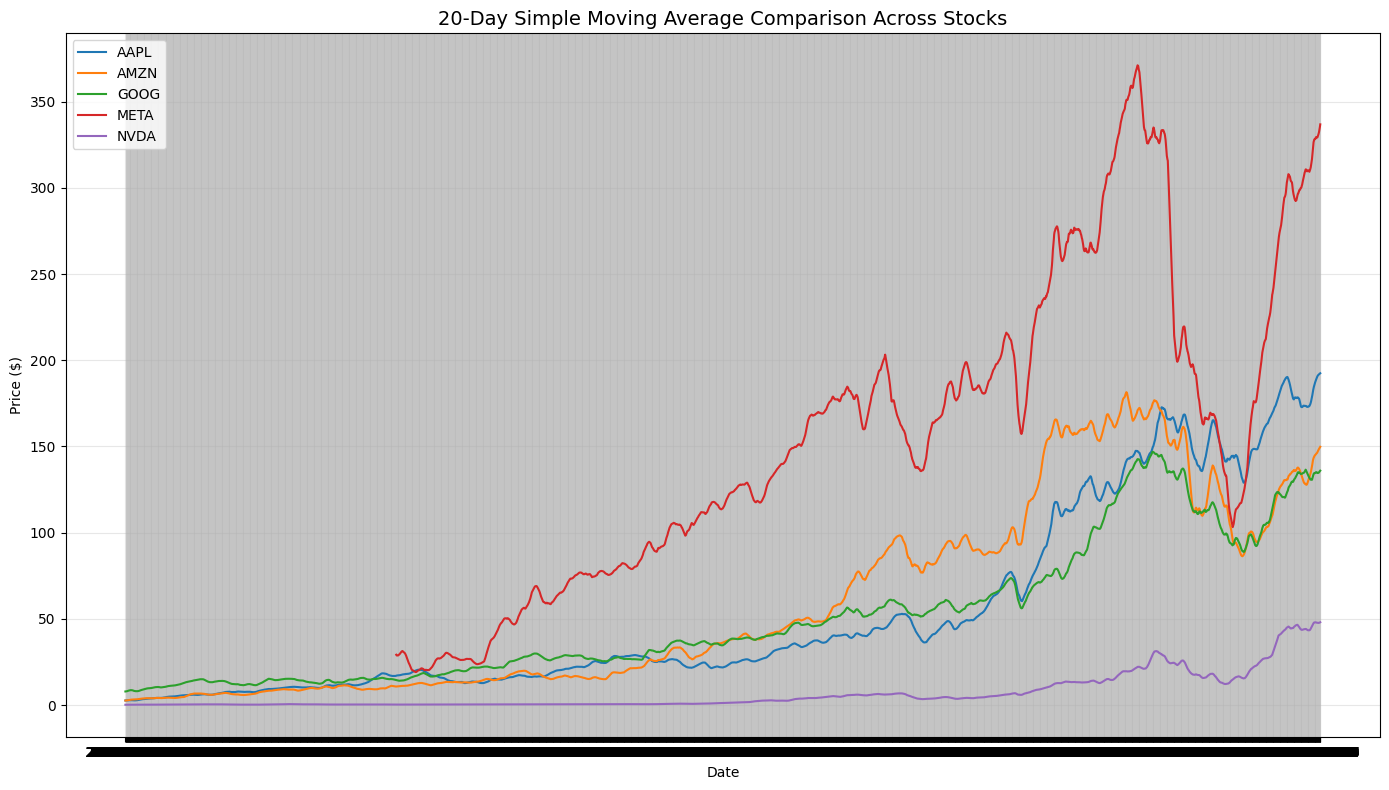

In [31]:
# Now create both graphs
for indicator, name in [('SMA_20', 'Simple Moving Average'), ('EMA_20', 'Exponential Moving Average')]:
    fig, ax = plt.subplots(figsize=(14, 8))
    for ticker in df_all_stocks['Ticker'].unique():
        data = df_all_stocks[df_all_stocks['Ticker'] == ticker].dropna(subset=[indicator])
        if len(data) > 0:
            ax.plot(data['Date'], data[indicator], label=ticker, linewidth=1.5)
    ax.set_title(f'20-Day {name} Comparison Across Stocks', fontsize=14)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{indicator.lower()}_comparison.png', dpi=150)
    plt.show()

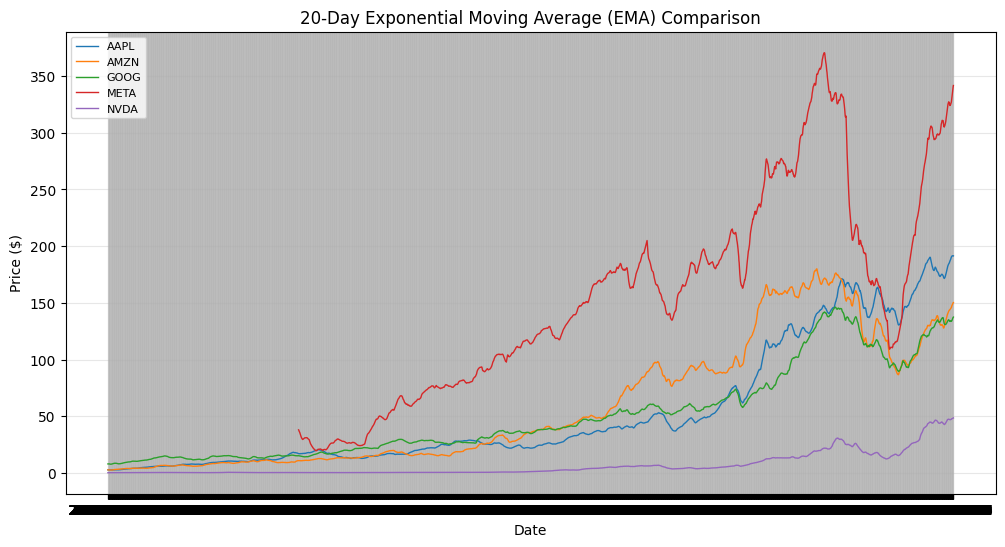

In [35]:
# Simplified EMA graph (no save, just display)
fig, ax = plt.subplots(figsize=(12, 6))

for ticker in df_all_stocks['Ticker'].unique():
    data = df_all_stocks[df_all_stocks['Ticker'] == ticker].dropna(subset=['EMA_20'])
    if len(data) > 0:
        ax.plot(data['Date'], data['EMA_20'], label=ticker, linewidth=1)

ax.set_title('20-Day Exponential Moving Average (EMA) Comparison', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

plt.show()